In [1]:
import itertools
import math
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from fairness_extensions import (
    bootstrap_impact_ratio,
    bootstrap_metric_difference,
    disparate_impact_table,
    infer_column_map,
    interaction_tests,
    paired_variant_tests,
    presentation_bullets,
    regression_with_controls,
    report_paragraphs,
    run_extended_fairness_suite,
    variance_checks,
)

warnings.filterwarnings("ignore")

# Reproducibility
RNG = np.random.default_rng(42)

In [2]:
# Output folders
OUTPUT_DIR = Path("outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Analysis schema
REQUIRED_COLUMNS = [
    "resume_id",
    "variant_id",
    "run_id",
    "model_name",
    "name_condition",
    "wording_condition",
    "qualification_tier",
    "hire_decision",
    "overall_score",
    "leadership_score",
    "experience_score",
    "skills_score",
]

VALID_NAME_CONDITIONS = {"male_coded", "female_coded"}
VALID_WORDING_CONDITIONS = {"neutral", "strong_leadership", "strong_technical"}
VALID_QUALIFICATION_TIERS = {"high", "medium", "mid", "low"}
VALID_HIRE_DECISIONS_TEXT = {"hire", "reject", "consider"}
CSV_PATH = Path("/Users/kavinphabiani/Documents/USC/DSCI531/531_final_project/final/Analysis Pipeline/similarity_scores_all .csv")


In [3]:
def load_and_prepare_outputs(
    csv_path: Path,
    consider_as_hire: bool = False,
    normalize_labels: bool = True,
) -> pd.DataFrame:
    """
    Load model outputs from CSV and normalize fields so the rest of the
    fairness pipeline can run on either synthetic data or model output files.

    Assumption used here:
    - hire -> 1
    - reject -> 0
    - consider -> 0 by default (set consider_as_hire=True to map it to 1)
    """
    df = pd.read_csv(csv_path).copy()

    if normalize_labels:
        df["qualification_tier"] = df["qualification_tier"].replace({
            "mid": "medium"
        })
        df["wording_condition"] = df["wording_condition"].replace({
            "strong_technical": "strong_technical",
            "strong_leadership": "strong_leadership",
        })

    df["hire_decision_raw"] = df["hire_decision"].astype(str).str.strip().str.lower()

    decision_map = {
        "hire": 1,
        "reject": 0,
        "consider": 1 if consider_as_hire else 0,
        "1": 1,
        "0": 0,
    }
    unknown_decisions = sorted(set(df["hire_decision_raw"]) - set(decision_map))
    if unknown_decisions:
        raise ValueError(f"Unexpected hire_decision values: {unknown_decisions}")

    df["hire_decision"] = df["hire_decision_raw"].map(decision_map).astype(int)

    numeric_cols = [
        "overall_score",
        "leadership_score",
        "experience_score",
        "skills_score",
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="raise")

    return df

In [4]:
df = load_and_prepare_outputs(CSV_PATH, consider_as_hire=False)
df.head(), df.shape


(      resume_id  variant_id                                run_id  \
 0  e89757ce5fd3  ACCOUNTANT  13b21643-42d0-4439-a634-a3867d1845d7   
 1  812e0deb4d5f  ACCOUNTANT  13b21643-42d0-4439-a634-a3867d1845d7   
 2  65658eeb249d  ACCOUNTANT  13b21643-42d0-4439-a634-a3867d1845d7   
 3  6cc2758f5c0c  ACCOUNTANT  13b21643-42d0-4439-a634-a3867d1845d7   
 4  10918a7be43a  ACCOUNTANT  13b21643-42d0-4439-a634-a3867d1845d7   
 
                model_name name_condition  wording_condition format_condition  \
 0  Qwen3.5-4B-GGUF:Q4_K_M   female_coded            neutral            clean   
 1  Qwen3.5-4B-GGUF:Q4_K_M   female_coded   strong_technical            clean   
 2  Qwen3.5-4B-GGUF:Q4_K_M     male_coded  strong_leadership            clean   
 3  Qwen3.5-4B-GGUF:Q4_K_M   female_coded   strong_technical            clean   
 4  Qwen3.5-4B-GGUF:Q4_K_M     male_coded            neutral            clean   
 
   qualification_tier  hire_decision  overall_score  ...  skills_score  \
 0             s

In [5]:
# def validate_outputs(df: pd.DataFrame) -> None:
#     missing_cols = [col for col in REQUIRED_COLUMNS if col not in df.columns]
#     if missing_cols:
#         raise ValueError(f"Missing required columns: {missing_cols}")

#     if not set(df["name_condition"]).issubset(VALID_NAME_CONDITIONS):
#         raise ValueError("Invalid values found in name_condition")

#     if not set(df["wording_condition"]).issubset(VALID_WORDING_CONDITIONS):
#         raise ValueError("Invalid values found in wording_condition")

#     if not set(df["qualification_tier"]).issubset({"high", "medium", "low"}):
#         raise ValueError("Invalid values found in qualification_tier")

#     if not set(df["hire_decision_raw"]).issubset(VALID_HIRE_DECISIONS_TEXT):
#         raise ValueError("Unexpected text values found in hire_decision_raw")

#     if not set(df["hire_decision"].unique()).issubset({0, 1}):
#         raise ValueError("hire_decision must contain only 0/1 after mapping")

#     print("Validation passed.")


In [6]:
# validate_outputs(df)

In [7]:
# summary_df = summarize_by_group(df)
# display(summary_df)


In [8]:
# summary_path = TABLE_DIR / "group_summary.csv"
# summary_df.to_csv(summary_path, index=False)
# print(f"Saved summary table to: {summary_path}")

In [9]:
def selection_rate_gap(df: pd.DataFrame) -> pd.DataFrame:
    sr = df.groupby("name_condition", as_index=False)["hire_decision"].mean()
    sr = sr.rename(columns={"hire_decision": "selection_rate"})

    male_sr = sr.loc[sr["name_condition"] == "male_coded", "selection_rate"].iloc[0]
    female_sr = sr.loc[sr["name_condition"] == "female_coded", "selection_rate"].iloc[0]

    gap_df = pd.DataFrame(
        [{
            "male_selection_rate": round(male_sr, 4),
            "female_selection_rate": round(female_sr, 4),
            "selection_rate_gap_male_minus_female": round(male_sr - female_sr, 4),
        }]
    )
    return gap_df

sr_gap_df = selection_rate_gap(df)
sr_gap_df

,male_selection_rate,female_selection_rate,selection_rate_gap_male_minus_female
0,0.0929,0.0857,0.0071


In [10]:
def bootstrap_group_means(df, group_col, value_col, n_boot=2000, alpha=0.05):
    results = []
    groups = df[group_col].unique()

    for group in groups:
        values = df[df[group_col] == group][value_col].values
        boot_means = []
        for _ in range(n_boot):
            sample = RNG.choice(values, size=len(values), replace=True)
            boot_means.append(sample.mean())

        mean_val = values.mean()
        lower = np.percentile(boot_means, 100 * (alpha / 2))
        upper = np.percentile(boot_means, 100 * (1 - alpha / 2))

        results.append({
            "condition": group,
            "metric": value_col,
            "mean": round(mean_val, 4),
            "ci_lower": round(lower, 4),
            "ci_upper": round(upper, 4)
        })
    return results

# Calculate CIs for Overall Score and Leadership Score by Name Condition
ci_results = []
ci_results.extend(bootstrap_group_means(df, "name_condition", "overall_score"))
ci_results.extend(bootstrap_group_means(df, "name_condition", "leadership_score"))

ci_df = pd.DataFrame(ci_results)
display(ci_df)

,condition,metric,mean,ci_lower,ci_upper
0,female_coded,overall_score,15.6000,13.2976,18.0048
1,male_coded,overall_score,15.3262,13.0974,17.6149
2,female_coded,leadership_score,3.9833,3.4523,4.5215
3,male_coded,leadership_score,3.9738,3.4473,4.5214


In [11]:
def run_group_stats(df: pd.DataFrame) -> pd.DataFrame:
    results = []

    # Preserve original test so existing statistical_tests output remains compatible.
    male_scores = df[df["name_condition"] == "male_coded"]["overall_score"]
    female_scores = df[df["name_condition"] == "female_coded"]["overall_score"]

    t_stat, p_val = stats.ttest_ind(male_scores, female_scores)
    results.append({
        "test": "independent_t_overall_score",
        "statistic": t_stat,
        "p_value": p_val,
    })

    return pd.DataFrame(results).round(6)


colmap = infer_column_map(df)
stats_df = run_group_stats(df)

# 1) Disparate impact tables
impact_gender_df = disparate_impact_table(
    df,
    group_col=colmap.gender,
    outcome_col=colmap.selected,
    reference_group="male_coded" if "male_coded" in set(df[colmap.gender]) else None,
)
impact_gender_df["group"] = impact_gender_df[colmap.gender]
impact_gender_df = impact_gender_df.rename(
    columns={
        "absolute_gap_vs_reference": "absolute_gap",
        "impact_ratio_vs_reference": "impact_ratio",
    }
)

impact_race_df = disparate_impact_table(df, group_col=colmap.race, outcome_col=colmap.selected)
impact_race_df["group"] = impact_race_df[colmap.race]
impact_race_df = impact_race_df.rename(
    columns={
        "absolute_gap_vs_reference": "absolute_gap",
        "impact_ratio_vs_reference": "impact_ratio",
    }
)

# 2) Bootstrap CIs (score difference, selection-rate difference, impact ratio)
boot_rows = []
if {"male_coded", "female_coded"}.issubset(set(df[colmap.gender])):
    score_boot = bootstrap_metric_difference(
        df,
        group_col=colmap.gender,
        group_a="female_coded",
        group_b="male_coded",
        metric_col=colmap.overall,
        seed=42,
    )
    boot_rows.append({"comparison": "female_minus_male", "metric": colmap.overall, "estimate": score_boot["estimate"], "ci_lower": score_boot["ci_lower"], "ci_upper": score_boot["ci_upper"], "n_a": score_boot["n_a"], "n_b": score_boot["n_b"]})

    sr_boot = bootstrap_metric_difference(
        df,
        group_col=colmap.gender,
        group_a="female_coded",
        group_b="male_coded",
        metric_col=colmap.selected,
        seed=42,
    )
    boot_rows.append({"comparison": "female_minus_male", "metric": "selection_rate", "estimate": sr_boot["estimate"], "ci_lower": sr_boot["ci_lower"], "ci_upper": sr_boot["ci_upper"], "n_a": sr_boot["n_a"], "n_b": sr_boot["n_b"]})

    ratio_boot = bootstrap_impact_ratio(
        df,
        group_col=colmap.gender,
        outcome_col=colmap.selected,
        protected_group="female_coded",
        reference_group="male_coded",
        seed=42,
    )
    boot_rows.append({"comparison": "female_vs_male", "metric": "impact_ratio", "estimate": ratio_boot["estimate"], "ci_lower": ratio_boot["ci_lower"], "ci_upper": ratio_boot["ci_upper"], "n_a": ratio_boot["n_protected"], "n_b": ratio_boot["n_reference"]})

bootstrap_fairness_df = pd.DataFrame(boot_rows).round(6)

# 3) Interaction tests
interaction_test_gender_df = interaction_tests(
    df,
    dem_col=colmap.gender,
    wording_col=colmap.wording,
    score_col=colmap.overall,
    outcome_col=colmap.selected,
)

interaction_test_race_df = pd.DataFrame()
if df[colmap.race].nunique() >= 2 and df.groupby(colmap.race).size().min() >= 5:
    interaction_test_race_df = interaction_tests(
        df,
        dem_col=colmap.race,
        wording_col=colmap.wording,
        score_col=colmap.overall,
        outcome_col=colmap.selected,
    )

# 4) Regression with controls
regression_overall_df = regression_with_controls(
    df,
    outcome_col=colmap.overall,
    demographic_cols=[colmap.gender, colmap.race],
    control_cols=[colmap.wording, colmap.qualification],
    logistic=False,
)

regression_selected_df = regression_with_controls(
    df,
    outcome_col=colmap.selected,
    demographic_cols=[colmap.gender, colmap.race],
    control_cols=[colmap.wording, colmap.qualification],
    logistic=True,
)

# 5) Paired tests using base resume matching
paired_rows = []
if {"male_coded", "female_coded"}.issubset(set(df[colmap.gender])):
    paired_rows.append(
        {
            "comparison": "female_vs_male_overall",
            **paired_variant_tests(
                df,
                base_id_col=colmap.base_id,
                condition_col=colmap.gender,
                metric_col=colmap.overall,
                first_group="female_coded",
                second_group="male_coded",
            ),
        }
    )

paired_tests_df = pd.DataFrame(paired_rows).round(6)

# 6) Variance checks across groups
variance_gender_df = variance_checks(df, group_col=colmap.gender, score_cols=[colmap.overall, colmap.leadership, colmap.experience, colmap.skills])
variance_race_df = variance_checks(df, group_col=colmap.race, score_cols=[colmap.overall, colmap.leadership, colmap.experience, colmap.skills])

# Narrative outputs for slide/report use
presentation_bullets_df = pd.DataFrame({"bullet": presentation_bullets(impact_gender_df[["group", "selection_rate", "impact_ratio", "reference_group", "passes_4_5_rule"]], interaction_test_gender_df, paired_tests_df)})
report_paragraphs_df = pd.DataFrame({"paragraph": report_paragraphs(bootstrap_fairness_df, pd.concat([regression_overall_df, regression_selected_df], ignore_index=True), pd.concat([variance_gender_df, variance_race_df], ignore_index=True))})

display(stats_df)
display(impact_gender_df)
display(impact_race_df)
display(bootstrap_fairness_df)
display(interaction_test_gender_df)
if not interaction_test_race_df.empty:
    display(interaction_test_race_df)
display(regression_overall_df.head(12))
display(regression_selected_df.head(12))
display(paired_tests_df)
display(variance_gender_df)
display(variance_race_df)
display(presentation_bullets_df)
display(report_paragraphs_df)

,test,statistic,p_value
0,independent_t_overall_score,-0.163174,0.870421


,name_condition,n,selection_rate,reference_group,absolute_gap,impact_ratio,passes_4_5_rule,small_sample_warning,group
1,male_coded,420,0.0929,male_coded,0.0000,1.0000,True,False,male_coded
0,female_coded,420,0.0857,male_coded,-0.0071,0.9231,True,False,female_coded


,race,n,selection_rate,reference_group,absolute_gap,impact_ratio,passes_4_5_rule,small_sample_warning,group
0,asian,154,0.0974,asian,0.0000,1.0000,True,False,asian
2,hispanic,203,0.0936,asian,-0.0038,0.9609,True,False,hispanic
4,white,161,0.0932,asian,-0.0042,0.9565,True,False,white
1,black,147,0.0884,asian,-0.0090,0.9079,True,False,black
3,unknown,175,0.0743,asian,-0.0231,0.7627,False,False,unknown


,comparison,metric,estimate,ci_lower,ci_upper,n_a,n_b
0,female_minus_male,overall_score,0.273810,-2.971786,3.592857,420,420
1,female_minus_male,selection_rate,-0.007143,-0.045238,0.030952,420,420
2,female_vs_male,impact_ratio,0.923077,0.588235,1.437562,420,420


,model_type,dependent_variable,term,statistic,p_value,effect_direction
0,ols_anova,overall_score,C(name_condition),0.204152,0.651507,n/a
1,ols_anova,overall_score,C(wording_condition),6.938347,0.001027,n/a
2,ols_anova,overall_score,C(name_condition):C(wording_condition),2.872836,0.057098,n/a
3,ols_anova,overall_score,Residual,NaN,NaN,n/a
4,logit,hire_decision,C(name_condition)[T.male_coded]:C(wording_cond...,1.219742,0.070914,positive
5,logit,hire_decision,C(name_condition)[T.male_coded]:C(wording_cond...,0.901739,0.177782,positive


...

,comparison,n_pairs,mean_diff_first_minus_second,paired_t_stat,paired_t_p,wilcoxon_stat,wilcoxon_p
0,female_vs_male_overall,0,NaN,NaN,NaN,NaN,NaN


,group_col,score_col,levene_stat,p_value,warning
0,name_condition,overall_score,0.026626,0.870421,
1,name_condition,leadership_score,0.000623,0.980085,
2,name_condition,experience_score,0.179408,0.671991,
3,name_condition,skills_score,0.001802,0.966153,


,group_col,score_col,levene_stat,p_value,warning
0,race,overall_score,0.502881,0.733642,
1,race,leadership_score,0.920953,0.451026,
2,race,experience_score,0.218229,0.928331,
3,race,skills_score,0.800928,0.524703,


,bullet
0,"male_coded selection rate=0.093, impact ratio=..."
1,"female_coded selection rate=0.086, impact rati..."
2,No statistically significant demographic x wor...
3,Matched within-resume test had only 0 pairs; i...


,paragraph
0,Bootstrap confidence intervals quantify uncert...
1,Regression models with controls (wording and q...
2,Variance checks using Levene's test flag 0 sco...
3,Interpretation is conservative: statistical no...


In [12]:
def group_interaction_summary(df: pd.DataFrame) -> pd.DataFrame:
    # Summary without pairing
    interaction = (
        df.groupby(["wording_condition", "name_condition"], as_index=False)
        .agg(
            mean_overall_score=("overall_score", "mean"),
            selection_rate=("hire_decision", "mean"),
            count=("overall_score", "count"),
        )
        .round(4)
    )
    return interaction

interaction_df = group_interaction_summary(df)
display(interaction_df)

,wording_condition,name_condition,mean_overall_score,selection_rate,count
0,neutral,female_coded,14.7442,0.0864,301
1,neutral,male_coded,11.7837,0.0571,245
2,strong_leadership,female_coded,12.2857,0.0714,56
3,strong_leadership,male_coded,19.8908,0.1429,119
4,strong_technical,female_coded,22.6349,0.0952,63
5,strong_technical,male_coded,21.1250,0.1429,56


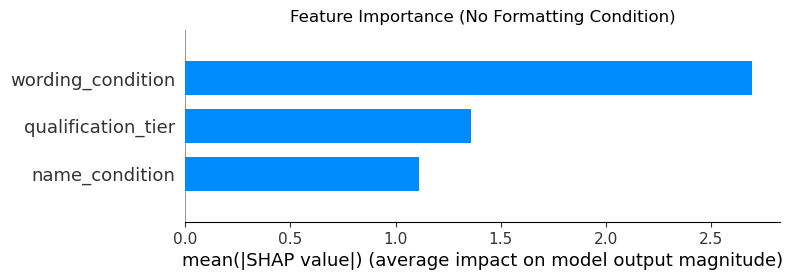

In [13]:
import shap
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare data for the model
df_ml = df.copy()
# Removed 'format_condition' from encoding
for col in ['name_condition', 'wording_condition', 'qualification_tier']:
    df_ml[col] = df_ml[col].astype('category').cat.codes

# Removed 'format_condition' from features
X = df_ml[['name_condition', 'wording_condition', 'qualification_tier']]
y = df_ml['overall_score']

# 2. Train a "Proxy Model"
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# 3. Calculate SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# 4. Visualize feature importance
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.title("Feature Importance (No Formatting Condition)")
plt.show()

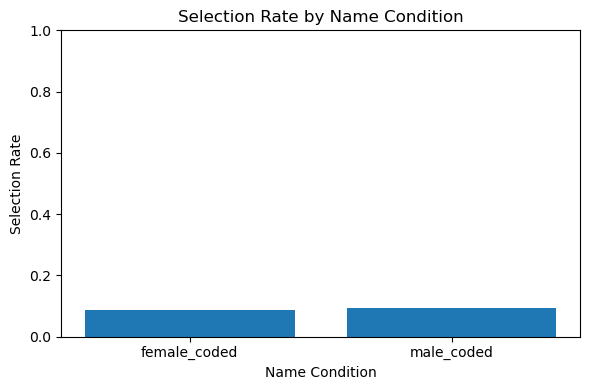

Saved figure to: outputs/figures/selection_rate_by_name_condition.png


In [14]:
plot_df = df.groupby("name_condition", as_index=False)["hire_decision"].mean()
plot_df = plot_df.rename(columns={"hire_decision": "selection_rate"})

plt.figure(figsize=(6, 4))
plt.bar(plot_df["name_condition"], plot_df["selection_rate"])
plt.title("Selection Rate by Name Condition")
plt.xlabel("Name Condition")
plt.ylabel("Selection Rate")
plt.ylim(0, 1)
plt.tight_layout()

fig_path = FIG_DIR / "selection_rate_by_name_condition.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print(f"Saved figure to: {fig_path}")

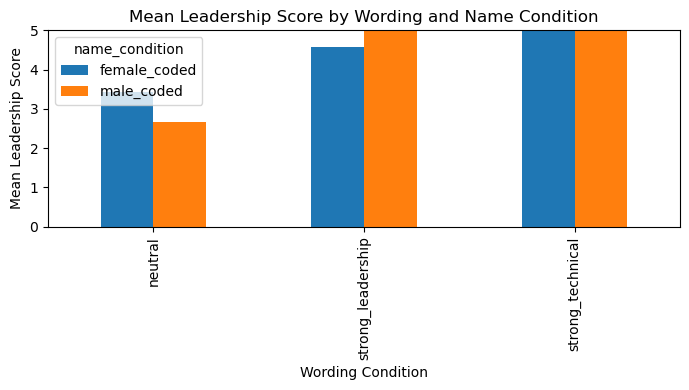

Saved figure to: outputs/figures/leadership_score_by_wording_and_name.png


In [15]:
plot_df = (
    df.groupby(["wording_condition", "name_condition"], as_index=False)["leadership_score"]
    .mean()
)

pivot_df = plot_df.pivot(
    index="wording_condition",
    columns="name_condition",
    values="leadership_score"
)

pivot_df.plot(kind="bar", figsize=(7, 4))
plt.title("Mean Leadership Score by Wording and Name Condition")
plt.xlabel("Wording Condition")
plt.ylabel("Mean Leadership Score")
plt.ylim(0, 5)
plt.tight_layout()

fig_path = FIG_DIR / "leadership_score_by_wording_and_name.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print(f"Saved figure to: {fig_path}")

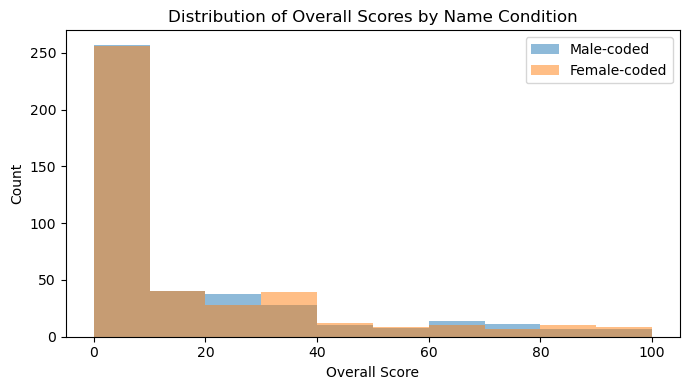

In [16]:
plt.figure(figsize=(7, 4))
plt.hist(df[df["name_condition"] == "male_coded"]["overall_score"], alpha=0.5, label="Male-coded")
plt.hist(df[df["name_condition"] == "female_coded"]["overall_score"], alpha=0.5, label="Female-coded")
plt.title("Distribution of Overall Scores by Name Condition")
plt.xlabel("Overall Score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()

fig_path = FIG_DIR / "overall_score_distribution.png"
plt.savefig(fig_path, dpi=200)
plt.show()

In [17]:
sr_gap_df.to_csv(TABLE_DIR / "selection_rate_gap.csv", index=False)
ci_df.to_csv(TABLE_DIR / "confidence_intervals.csv", index=False)
stats_df.to_csv(TABLE_DIR / "statistical_tests.csv", index=False)
interaction_df.to_csv(TABLE_DIR / "interaction_summary.csv", index=False)

# New fairness outputs (additive, preserving existing outputs)
impact_gender_df.to_csv(TABLE_DIR / "disparate_impact_gender.csv", index=False)
impact_race_df.to_csv(TABLE_DIR / "disparate_impact_race.csv", index=False)
bootstrap_fairness_df.to_csv(TABLE_DIR / "bootstrap_fairness_ci.csv", index=False)
interaction_test_gender_df.to_csv(TABLE_DIR / "interaction_tests_gender_wording.csv", index=False)
if not interaction_test_race_df.empty:
    interaction_test_race_df.to_csv(TABLE_DIR / "interaction_tests_race_wording.csv", index=False)
regression_overall_df.to_csv(TABLE_DIR / "regression_controls_overall.csv", index=False)
regression_selected_df.to_csv(TABLE_DIR / "regression_controls_selection.csv", index=False)
paired_tests_df.to_csv(TABLE_DIR / "paired_variant_tests.csv", index=False)
variance_gender_df.to_csv(TABLE_DIR / "variance_checks_gender.csv", index=False)
variance_race_df.to_csv(TABLE_DIR / "variance_checks_race.csv", index=False)
presentation_bullets_df.to_csv(TABLE_DIR / "presentation_bullets.csv", index=False)
report_paragraphs_df.to_csv(TABLE_DIR / "report_paragraphs.csv", index=False)

print("Saved existing and extended fairness-analysis tables.")

Saved existing and extended fairness-analysis tables.


In [18]:
def summarize_by_race(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby("race", as_index=False)
        .agg(
            count=("resume_id", "count"),
            selection_rate=("hire_decision", "mean"),
            mean_overall_score=("overall_score", "mean"),
            mean_leadership_score=("leadership_score", "mean"),
            mean_experience_score=("experience_score", "mean"),
            mean_skills_score=("skills_score", "mean"),
        )
        .round(4)
    )

In [19]:
race_summary_df = summarize_by_race(df)
display(race_summary_df)

,race,count,selection_rate,mean_overall_score,mean_leadership_score,mean_experience_score,mean_skills_score
0,asian,154,0.0974,15.1299,3.8117,4.1818,7.2013
1,black,147,0.0884,16.2585,3.8435,4.3878,8.0952
2,hispanic,203,0.0936,15.7192,4.3153,4.2069,7.3941
3,unknown,175,0.0743,13.4457,3.4400,3.6000,6.4629
4,white,161,0.0932,16.9255,4.4224,4.0497,8.6708


In [20]:
race_summary_path = TABLE_DIR / "race_summary.csv"
race_summary_df.to_csv(race_summary_path, index=False)
print(f"Saved race summary table to: {race_summary_path}")

Saved race summary table to: outputs/tables/race_summary.csv


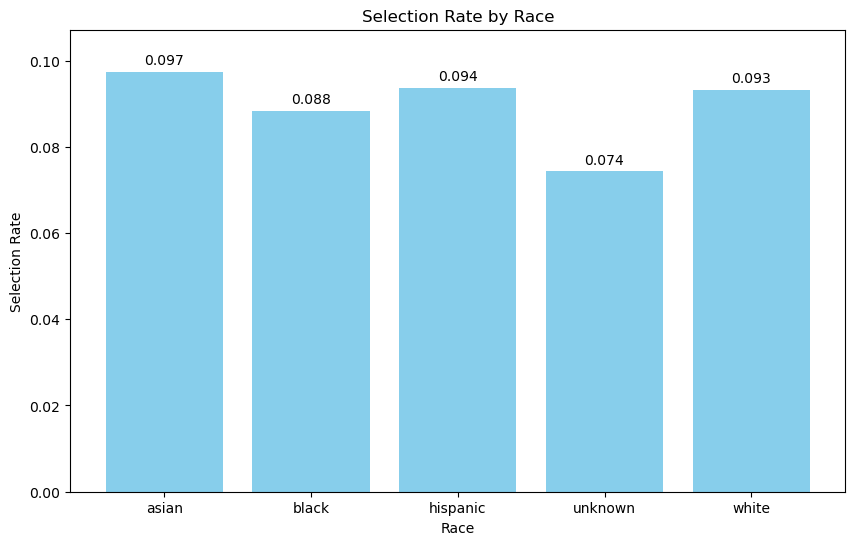

In [21]:
# Visualization: Selection Rate by Race
plt.figure(figsize=(10, 6))
plt.bar(race_summary_df['race'], race_summary_df['selection_rate'], color='skyblue')
plt.title('Selection Rate by Race')
plt.xlabel('Race')
plt.ylabel('Selection Rate')
plt.ylim(0, max(race_summary_df['selection_rate']) * 1.1)
for i, v in enumerate(race_summary_df['selection_rate']):
    plt.text(i, v + 0.001, f'{v:.3f}', ha='center', va='bottom')
plt.savefig(FIG_DIR / 'selection_rate_by_race.png', dpi=300, bbox_inches='tight')
plt.show()

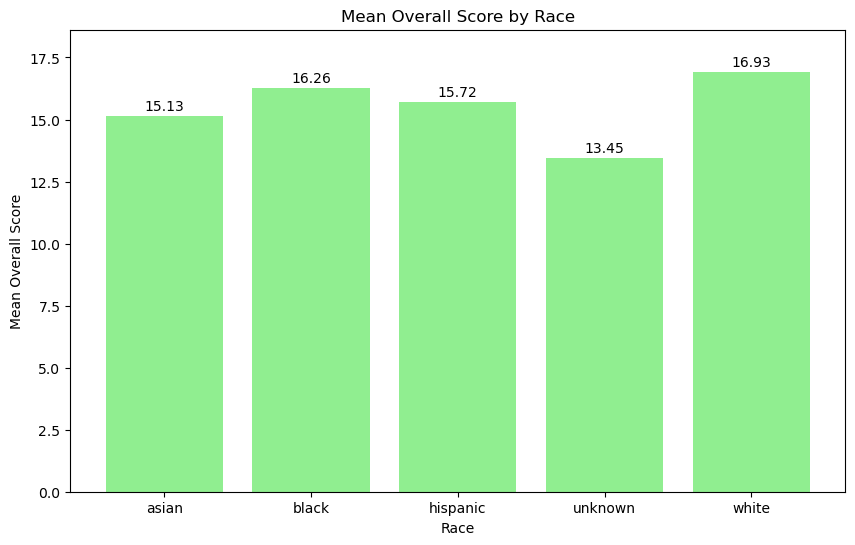

In [22]:
# Visualization: Mean Overall Score by Race
plt.figure(figsize=(10, 6))
plt.bar(race_summary_df['race'], race_summary_df['mean_overall_score'], color='lightgreen')
plt.title('Mean Overall Score by Race')
plt.xlabel('Race')
plt.ylabel('Mean Overall Score')
plt.ylim(0, max(race_summary_df['mean_overall_score']) * 1.1)
for i, v in enumerate(race_summary_df['mean_overall_score']):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom')
plt.savefig(FIG_DIR / 'mean_overall_score_by_race.png', dpi=300, bbox_inches='tight')
plt.show()

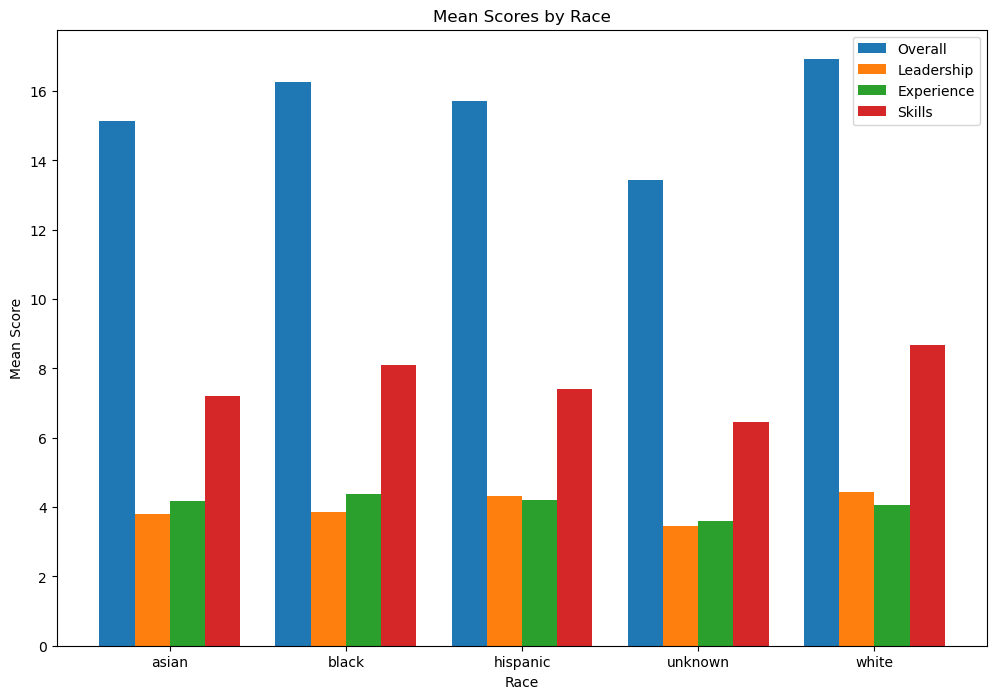

In [23]:
# Visualization: Mean Scores by Race (Grouped Bar)
score_cols = ['mean_overall_score', 'mean_leadership_score', 'mean_experience_score', 'mean_skills_score']
score_labels = ['Overall', 'Leadership', 'Experience', 'Skills']

x = np.arange(len(race_summary_df['race']))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 8))
for i, (col, label) in enumerate(zip(score_cols, score_labels)):
    ax.bar(x + i*width, race_summary_df[col], width, label=label)

ax.set_xlabel('Race')
ax.set_ylabel('Mean Score')
ax.set_title('Mean Scores by Race')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(race_summary_df['race'])
ax.legend()
plt.savefig(FIG_DIR / 'mean_scores_by_race_grouped.png', dpi=300, bbox_inches='tight')
plt.show()

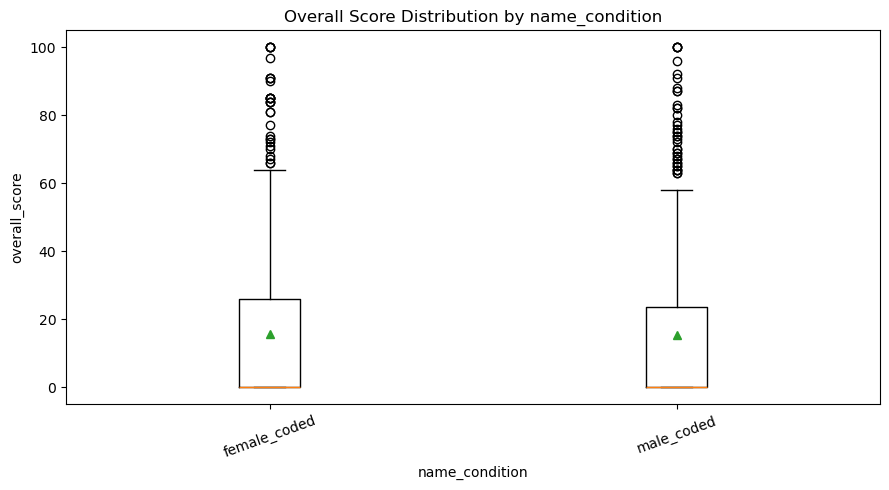

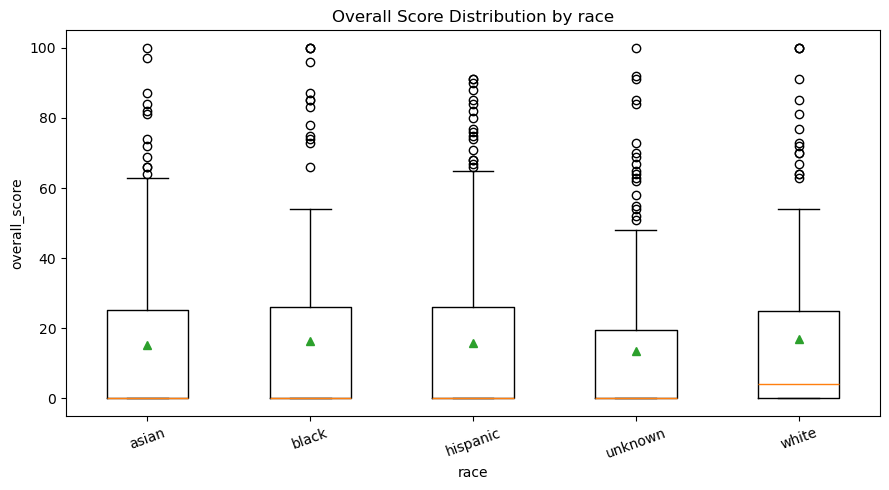

In [24]:
# Additional distribution checks for fairness stability
for group_col, fig_name in [(colmap.gender, "overall_score_distribution_by_gender.png"), (colmap.race, "overall_score_distribution_by_race.png")]:
    plt.figure(figsize=(9, 5))
    groups = [g for g in sorted(df[group_col].dropna().unique())]
    values = [df.loc[df[group_col] == g, colmap.overall].dropna().values for g in groups]
    if len(groups) >= 2 and all(len(v) > 0 for v in values):
        plt.boxplot(values, labels=groups, showmeans=True)
        plt.title(f"Overall Score Distribution by {group_col}")
        plt.xlabel(group_col)
        plt.ylabel(colmap.overall)
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.savefig(FIG_DIR / fig_name, dpi=300, bbox_inches="tight")
        plt.show()
    else:
        print(f"Skipping {fig_name}: insufficient data.")

In [25]:
from fairness_extensions import run_extended_fairness_suite
# Optional one-call orchestrator for all extended fairness outputs
suite_results = run_extended_fairness_suite(df, n_boot=2000, seed=42)

# Save all orchestrator tables with consistent names
for table_name, table_df in suite_results.items():
    table_df.to_csv(TABLE_DIR / f"{table_name}.csv", index=False)

print("Extended fairness suite tables saved via run_extended_fairness_suite().")
display(suite_results["disparate_impact_gender"])
display(suite_results["bootstrap_fairness_ci"])
display(suite_results["paired_variant_tests"])
display(suite_results["presentation_bullets"])
display(suite_results["report_paragraphs"])

Extended fairness suite tables saved via run_extended_fairness_suite().


,name_condition,n,selection_rate,reference_group,absolute_gap,impact_ratio,passes_4_5_rule,small_sample_warning,group
1,male_coded,420,0.0929,male_coded,0.0000,1.0000,True,False,male_coded
0,female_coded,420,0.0857,male_coded,-0.0071,0.9231,True,False,female_coded


,comparison,metric,estimate,ci_lower,ci_upper,n_a,n_b
0,female_minus_male,overall_score,0.273810,-2.964286,3.597738,420,420
1,female_minus_male,selection_rate,-0.007143,-0.045238,0.033333,420,420
2,female_vs_male,impact_ratio,0.923077,0.595153,1.444444,420,420


,comparison,n_pairs,mean_diff_first_minus_second,paired_t_stat,paired_t_p,wilcoxon_stat,wilcoxon_p,warning
0,female_vs_male_overall,0,NaN,NaN,NaN,NaN,NaN,Insufficient matched pairs for robust inference.


,bullet
0,"male_coded selection rate=0.093, impact ratio=..."
1,"female_coded selection rate=0.086, impact rati..."
2,No statistically significant demographic x wor...
3,Matched within-resume test had only 0 pairs; i...


,paragraph
0,Bootstrap confidence intervals quantify uncert...
1,Regression models with controls (wording and q...
2,Variance checks using Levene's test flag 0 sco...
3,Interpretation is conservative: statistical no...
